In [1]:
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [2]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=fb516fd13e3eb2618a20fcad14c72cbc22195e5f379e7207f99d1c30ef5ae478
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [3]:
import pandas as pd
import numpy as np
import spacy
from IPython.display import Image


import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# How inshorts delivers news in less than 60 words

* Inshorts is a news app started in 2013 which delivers news in less than 60 words.
* In this business use case we will look at how we can train a news summarisation model using Recurrent Neural Networks.
* This means that when we pass an input of M words, it outputs N words which is the summary of the News article where N<M.
* In this business case we will try to summarize news which are 40-60 words in less than 30 words.

In [4]:
# Setup some configuration parameters

config = {'min_text_len':40,
          'max_text_len':60,
          'max_summary_len':30,
          'latent_dim' : 300,
          'embedding_dim' : 200}

---
# Reading the dataset
---

In [5]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [6]:
!gdown 1sui9RXxVsPDa4s2kooQwRGhb8taZhcgD
!gdown 1H3gdo7SLBiWE_GGD6_xcdAp2wJJFcd5L

Downloading...
From: https://drive.google.com/uc?id=1sui9RXxVsPDa4s2kooQwRGhb8taZhcgD
To: /content/news_summary.csv
100% 11.9M/11.9M [00:00<00:00, 108MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1H3gdo7SLBiWE_GGD6_xcdAp2wJJFcd5L
To: /content/news_summary_more.csv
100% 41.4M/41.4M [00:00<00:00, 159MB/s]


In [7]:
!pip install rouge-score

In [8]:
from rouge_score import rouge_scorer

summary = pd.read_csv('news_summary.csv', encoding='iso-8859-1')
raw = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

raw = raw.rename(columns = {'headlines':'summary'})
summary = summary[['headlines', 'text']].rename(columns={'headlines':'summary'})

# Concatenate the summary and the raw files
df = pd.concat([raw, summary]).reset_index(drop=True)

summary.shape, raw.shape

((4514, 2), (98401, 2))

In [9]:
df

,summary,text
0,upGrad learner switches to career in ML & Al w...,"Saurav Kant, an alumnus of upGrad and IIIT-B's..."
1,Delhi techie wins free food from Swiggy for on...,Kunal Shah's credit card bill payment platform...
2,New Zealand end Rohit Sharma-led India's 12-ma...,New Zealand defeated India by 8 wickets in the...
3,Aegon life iTerm insurance plan helps customer...,"With Aegon Life iTerm Insurance plan, customer..."
4,"Have known Hirani for yrs, what if MeToo claim...",Speaking about the sexual harassment allegatio...
...,...,...
102910,Rasna seeking ?250 cr revenue from snack categ...,Fruit juice concentrate maker Rasna is eyeing ...
102911,Sachin attends Rajya Sabha after questions on ...,Former Indian cricketer Sachin Tendulkar atten...
102912,Shouldn't rob their childhood: Aamir on kids r...,"Aamir Khan, while talking about reality shows ..."
102913,"Asha Bhosle gets ?53,000 power bill for unused...",The Maharashtra government has initiated an in...


### Distribution of words before filtering

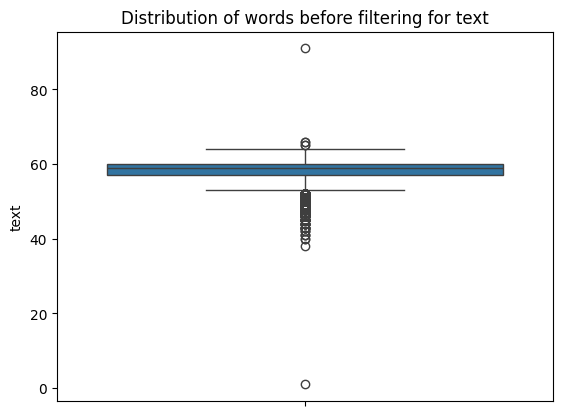

In [10]:
sns.boxplot(df['text'].apply(lambda x:len(x.split())))
plt.title('Distribution of words before filtering for text')
plt.show()

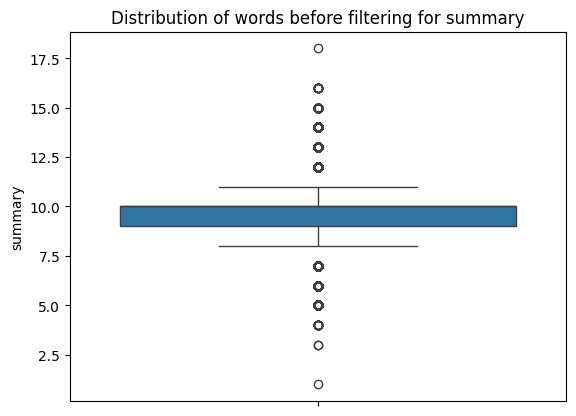

In [11]:
sns.boxplot(df['summary'].apply(lambda x:len(x.split())))
plt.title('Distribution of words before filtering for summary')
plt.show()

In [12]:
print(f'before filtering{df.shape}')
text_lengths = df['text'].apply(lambda x:len(x.split()))
pre = df[(text_lengths > config['min_text_len']) & (text_lengths < config['max_text_len'])]
print(f'After filtering: {pre.shape}')

before filtering(102915, 2)
After filtering: (57869, 2)


In [13]:
pre

,summary,text
5,Rahat Fateh Ali Khan denies getting notice for...,Pakistani singer Rahat Fateh Ali Khan has deni...
6,"India get all out for 92, their lowest ODI tot...",India recorded their lowest ODI total in New Z...
8,Called PM Modi 'sir' 10 times to satisfy his e...,Andhra Pradesh CM N Chandrababu Naidu has said...
11,81-yr-old woman conducts physical training in ...,"Isha Ghosh, an 81-year-old member of Bharat Sc..."
16,"Karan Johar, Tabu turn showstoppers on opening...",Filmmaker Karan Johar and actress Tabu turned ...
...,...,...
102906,Prosthetic fingers on sale to rig UP election:...,An investigation by India Today has unmasked a...
102907,"Kangana, Shahid, Saif starrer 'Rangoon' hits t...","The Kangana Ranaut, Shahid Kapoor and Saif Ali..."
102909,Ticket collector bites off senior officer?s no...,A ticket collector on Thursday allegedly bit o...
102912,Shouldn't rob their childhood: Aamir on kids r...,"Aamir Khan, while talking about reality shows ..."


### Distribution of words after filtering

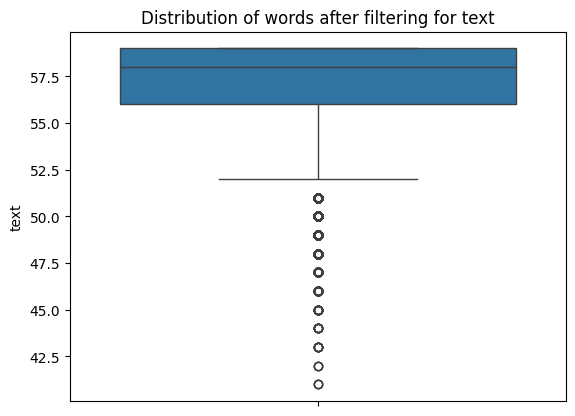

In [14]:
sns.boxplot(pre['text'].apply(lambda x:len(x.split())))
plt.title('Distribution of words after filtering for text')
plt.show()

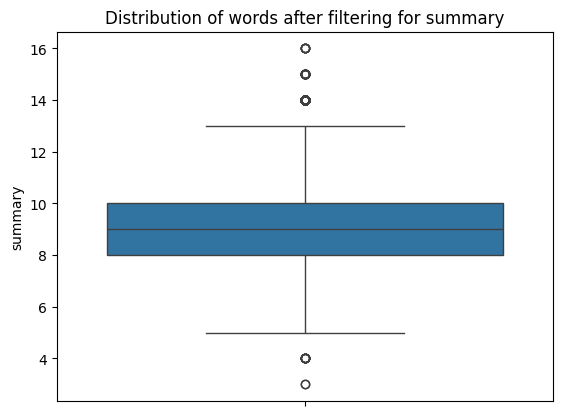

In [15]:
sns.boxplot(pre['summary'].apply(lambda x:len(x.split())))
plt.title('Distribution of words after filtering for summary')
plt.show()

In [16]:
ind = 3
print(f'Text: {pre.iloc[ind].text}')
print()
print(f'Summary: {pre.iloc[ind].summary}')
print()
print(f'Text length: {len(pre.iloc[ind].text.split())}')
print(f'Summary length: {len(pre.iloc[ind].summary.split())}')

Text: Isha Ghosh, an 81-year-old member of Bharat Scouts and Guides (BSG), has been imparting physical and mental training to schoolchildren in Jharkhand for several decades. Chaibasa-based Ghosh reportedly walks seven kilometres daily and spends eight hours conducting physical training, apart from climbing and yoga sessions. She says, "One should do something for society till one's last breath."

Summary: 81-yr-old woman conducts physical training in J'khand schools

Text length: 57
Summary length: 8


In [17]:
max(pre['text'].apply(lambda x:len(x.split())))

59

In [18]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Embedding, Input, InputLayer, RNN, SimpleRNN, LSTM, GRU, TimeDistributed
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf

import string
import spacy

import nltk

from nltk.corpus import stopwords
stop_words = stopwords.words('english')

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

### Text Cleaning using spaCy

In [19]:
import re

# Remove non-alphabetic characters (Data Cleaning)
def text_strip(sentence):

    sentence = re.sub("(\\t)", " ", str(sentence)).lower()
    sentence = re.sub("(\\r)", " ", str(sentence)).lower()
    sentence = re.sub("(\\n)", " ", str(sentence)).lower()

    # Remove - if it occurs more than one time consecutively
    sentence = re.sub("(--+)", " ", str(sentence)).lower()

    # Remove . if it occurs more than one time consecutively
    sentence = re.sub("(\.\.+)", " ", str(sentence)).lower()

    # Remove the characters - <>()|&©ø"',;?~*!
    sentence = re.sub(r"[<>()|&©ø\[\]\'\",;?~*!]", " ", str(sentence)).lower()

    # Remove \x9* in text
    sentence = re.sub(r"(\\x9\d)", " ", str(sentence)).lower()

    # Replace CM# and CHG# to CM_NUM
    sentence = re.sub("([cC][mM]\d+)|([cC][hH][gG]\d+)", "CM_NUM", str(sentence)).lower()

    # Remove punctuations at the end of a word
    sentence = re.sub("(\.\s+)", " ", str(sentence)).lower()
    sentence = re.sub("(\-\s+)", " ", str(sentence)).lower()
    sentence = re.sub("(\:\s+)", " ", str(sentence)).lower()

    # Remove multiple spaces
    sentence = re.sub("(\s+)", " ", str(sentence)).lower()

    return sentence

# Get the cleaned text and Add start, end tokens

In [20]:
pre['cleaned_text'] = pre.text.apply(lambda x: text_strip(x))
pre['cleaned_summary'] = pre.summary.apply(lambda x: '_START_ '+ text_strip(x) + ' _END_')
pre['cleaned_summary'] = pre['cleaned_summary'].apply(lambda x: 'sostok ' + x + ' eostok')
pre

,summary,text,cleaned_text,cleaned_summary
5,Rahat Fateh Ali Khan denies getting notice for...,Pakistani singer Rahat Fateh Ali Khan has deni...,pakistani singer rahat fateh ali khan has deni...,sostok _START_ rahat fateh ali khan denies get...
6,"India get all out for 92, their lowest ODI tot...",India recorded their lowest ODI total in New Z...,india recorded their lowest odi total in new z...,sostok _START_ india get all out for 92 their ...
8,Called PM Modi 'sir' 10 times to satisfy his e...,Andhra Pradesh CM N Chandrababu Naidu has said...,andhra pradesh cm n chandrababu naidu has said...,sostok _START_ called pm modi sir 10 times to ...
11,81-yr-old woman conducts physical training in ...,"Isha Ghosh, an 81-year-old member of Bharat Sc...",isha ghosh an 81-year-old member of bharat sco...,sostok _START_ 81-yr-old woman conducts physic...
16,"Karan Johar, Tabu turn showstoppers on opening...",Filmmaker Karan Johar and actress Tabu turned ...,filmmaker karan johar and actress tabu turned ...,sostok _START_ karan johar tabu turn showstopp...
...,...,...,...,...
102906,Prosthetic fingers on sale to rig UP election:...,An investigation by India Today has unmasked a...,an investigation by india today has unmasked a...,sostok _START_ prosthetic fingers on sale to r...
102907,"Kangana, Shahid, Saif starrer 'Rangoon' hits t...","The Kangana Ranaut, Shahid Kapoor and Saif Ali...",the kangana ranaut shahid kapoor and saif ali ...,sostok _START_ kangana shahid saif starrer ran...
102909,Ticket collector bites off senior officer?s no...,A ticket collector on Thursday allegedly bit o...,a ticket collector on thursday allegedly bit o...,sostok _START_ ticket collector bites off seni...
102912,Shouldn't rob their childhood: Aamir on kids r...,"Aamir Khan, while talking about reality shows ...",aamir khan while talking about reality shows o...,sostok _START_ shouldn t rob their childhood a...


In [21]:
print(pre.shape)
post_pre = pre[((pre.cleaned_text.str.split().str.len()<=config['max_text_len']) &
                (pre.summary.str.split().str.len()<=(config['max_summary_len']+4)))].copy()
post_pre = post_pre.reset_index(drop=True)
print(post_pre.shape)

post_pre = post_pre.drop(['text', 'summary'], axis=1)
post_pre = post_pre.rename(columns = {'cleaned_text':'text',
                                      'cleaned_summary':'summary'})
post_pre

(57869, 4)
(49902, 4)


,text,summary
0,pakistani singer rahat fateh ali khan has deni...,sostok _START_ rahat fateh ali khan denies get...
1,india recorded their lowest odi total in new z...,sostok _START_ india get all out for 92 their ...
2,andhra pradesh cm n chandrababu naidu has said...,sostok _START_ called pm modi sir 10 times to ...
3,isha ghosh an 81-year-old member of bharat sco...,sostok _START_ 81-yr-old woman conducts physic...
4,filmmaker karan johar and actress tabu turned ...,sostok _START_ karan johar tabu turn showstopp...
...,...,...
49897,indian captain virat kohli on friday got out w...,sostok _START_ virat kohli out for a duck for ...
49898,srinivas kunchubhotla 32 an indian engineer wa...,sostok _START_ indian shot dead in us over all...
49899,an investigation by india today has unmasked a...,sostok _START_ prosthetic fingers on sale to r...
49900,a ticket collector on thursday allegedly bit o...,sostok _START_ ticket collector bites off seni...


In [22]:
x_train, x_valid, y_train, y_valid = train_test_split(np.array(post_pre["text"]),
                                            np.array(post_pre["summary"]),
                                            test_size=0.1,
                                            random_state=0,
                                            shuffle=True
                                           )

x_train.shape, x_valid.shape, y_train.shape, y_valid.shape

((44911,), (4991,), (44911,), (4991,))

In [23]:
def get_rare_words(text_col):

    # Prepare a tokenizer on testing data
    text_tokenizer = Tokenizer()
    text_tokenizer.fit_on_texts(list(text_col))

    thresh = 5

    cnt = 0
    tot_cnt = 0

    for key, value in text_tokenizer.word_counts.items():
        tot_cnt = tot_cnt + 1
        if value < thresh:
            cnt = cnt + 1

    print("% of rare words in vocabulary:",(cnt / tot_cnt) * 100)

    return cnt, tot_cnt

In [24]:
x_train_cnt, x_train_tot_cnt = get_rare_words(text_col=x_train)

% of rare words in vocabulary: 63.99226679555341


In [25]:
# Prepare a tokenizer, again -- by not considering the rare words
x_tokenizer = Tokenizer(num_words=x_train_tot_cnt - x_train_cnt)
# x_tokenizer = Tokenizer(num_words = x_train_tot_cnt)
x_tokenizer.fit_on_texts(list(x_train))

# Convert text sequences to integer sequences
x_tr_seq = x_tokenizer.texts_to_sequences(x_train)
x_val_seq = x_tokenizer.texts_to_sequences(x_valid)

# Pad zero upto maximum length
x_tr = pad_sequences(x_tr_seq,  maxlen=config['max_text_len'], padding='post')
x_val = pad_sequences(x_val_seq, maxlen=config['max_text_len'], padding='post')

# Size of vocabulary (+1 for padding token)
x_voc = x_tokenizer.num_words + 1

print("Size of vocabulary in X = {}".format(x_voc))

Size of vocabulary in X = 21606


In [26]:
x_tr[5]

array([ 3659,  2685,  1531,    13,   167,     6,    82,   272,    34,
         332,     7,   106,    20,     3,  5494,  5167,  3620,   582,
           1,    48,  1235,     5,  1775, 12967,  5495,     4,   327,
          45,    12,    70,   155,  4687,     2,  1199,  3688,   240,
           3,   141,    81, 19474,    22,     1, 12967,     1,   141,
          13,    62,  7852,    68,  6879,     2,  8037,  1877,   236,
          44,   240,     0,     0,     0,     0], dtype=int32)

So, x_tr[5] retrieves the sixth complete sequence (since Python uses 0-based indexing) of the padded text data. Each number in this sequence corresponds to a word in your vocabulary, and the 0s are padding added to make all sequences the same length

In [29]:
y_train_cnt, y_train_tot_cnt = get_rare_words(text_col=y_train)

% of rare words in vocabulary: 66.05820105820106


In [30]:
# Prepare a tokenizer, again -- by not considering the rare words
y_tokenizer = Tokenizer(num_words=y_train_tot_cnt - y_train_cnt)
# y_tokenizer = Tokenizer(num_words=y_train_tot_cnt)
y_tokenizer.fit_on_texts(list(y_train))

# Convert text sequences to integer sequences
y_tr_seq = y_tokenizer.texts_to_sequences(y_train)
y_val_seq = y_tokenizer.texts_to_sequences(y_valid)

# Pad zero upto maximum length
y_tr = pad_sequences(y_tr_seq, maxlen=config['max_summary_len'], padding='post')
y_val = pad_sequences(y_val_seq, maxlen=config['max_summary_len'], padding='post')

# Size of vocabulary (+1 for padding token)
y_voc = y_tokenizer.num_words + 1

print("Size of vocabulary in Y = {}".format(y_voc))

Size of vocabulary in Y = 8982


In [31]:
y_tokenizer

In [39]:
y_tr

array([[   3,    2, 1659, ...,    0,    0,    0],
       [   3,    2,  859, ...,    0,    0,    0],
       [   3,    2, 2764, ...,    0,    0,    0],
       ...,
       [   3,    2, 1474, ...,    0,    0,    0],
       [   3,    2, 1262, ...,    0,    0,    0],
       [   3,    2,    9, ...,    0,    0,    0]], dtype=int32)

In [32]:
y_tr_seq

[[3, 2, 1659, 343, 259, 339, 810, 101, 7199, 6067, 1157, 794, 1, 4],
 [3, 2, 859, 79, 2302, 20, 43, 173, 202, 5, 905, 311, 860, 1, 4],
 [3, 2, 2764, 380, 17, 5, 25, 3196, 205, 21, 1087, 920, 447, 1, 4],
 [3, 2, 57, 126, 75, 42, 335, 893, 210, 4966, 6, 425, 651, 1, 4],
 [3, 2, 27, 39, 304, 550, 16, 1106, 1900, 1, 4],
 [3, 2, 41, 6570, 67, 43, 226, 6, 1855, 13, 6571, 233, 2438, 1, 4],
 [3, 2, 385, 9, 2061, 7, 177, 1, 4],
 [3, 2, 3982, 109, 155, 16, 6572, 6573, 6574, 6068, 2505, 321, 1, 4],
 [3, 2, 27, 7, 542, 5, 25, 3197, 14, 1286, 470, 1, 4],
 [3, 2, 234, 207, 31, 1107, 1465, 8, 1182, 82, 951, 65, 1, 4],
 [3, 2, 7200, 4212, 726, 3198, 3821, 2232, 6069, 1, 4],
 [3, 2, 6070, 5, 25, 747, 7, 659, 1108, 840, 1108, 374, 1, 4],
 [3, 2, 2765, 3983, 232, 2367, 1409, 221, 3641, 1, 4],
 [3, 2, 167, 619, 305, 16, 4452, 1734, 14, 122, 906, 124, 1, 4],
 [3, 2, 4967, 625, 795, 69, 2233, 47, 7980, 1141, 1466, 1467, 1, 4],
 [3, 2, 28, 80, 1410, 2439, 10, 108, 2979, 523, 10, 3468, 1, 4],
 [3, 2, 492, 11,

In [33]:
y_train_cnt, y_train_tot_cnt = get_rare_words(text_col=y_train)

% of rare words in vocabulary: 66.05820105820106


# Initialize the Encoder and Decoder architecture

In [34]:
config

{'min_text_len': 40,
 'max_text_len': 60,
 'max_summary_len': 30,
 'latent_dim': 300,
 'embedding_dim': 200}

In [35]:
latent_dim = config['latent_dim']
embedding_dim = config['embedding_dim']
max_text_len = config['max_text_len']
max_summary_len = config['max_summary_len']

# Encoder
encoder_inputs = Input(shape=(max_text_len, ))

enc_emb = Embedding(x_voc, embedding_dim,
                    trainable=True)(encoder_inputs)

encoder_lstm1 = LSTM(latent_dim, return_sequences=True,
                     return_state=True, dropout=0.4,
                     recurrent_dropout=0.4)
(encoder_output1, state_h1, state_c1) = encoder_lstm1(enc_emb)

encoder_lstm2 = LSTM(latent_dim, return_sequences=True,
                     return_state=True, dropout=0.4,
                     recurrent_dropout=0.4)
(encoder_output2, state_h2, state_c2) = encoder_lstm2(encoder_output1)

encoder_lstm3 = LSTM(latent_dim, return_state=True,
                     return_sequences=True, dropout=0.4,
                     recurrent_dropout=0.4)
(encoder_outputs, state_h, state_c) = encoder_lstm3(encoder_output2)

decoder_inputs = Input(shape=(None, ))

dec_emb_layer = Embedding(y_voc, embedding_dim, trainable=True)
dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True,
                    return_state=True, dropout=0.4,
                    recurrent_dropout=0.2)
(decoder_outputs, decoder_fwd_state, decoder_back_state) = \
    decoder_lstm(dec_emb, initial_state=[state_h, state_c])

decoder_dense = TimeDistributed(Dense(y_voc, activation='softmax'))
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 60, 200)   │  4,321,200 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 60, 300), │    601,200 │ embedding[0][0]   │
│                     │ (None, 300),      │            │                   │
│                     │ (None, 300)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 60, 300), │    721,200 │ lstm[0][0]        │
│                     │ (None, 300),      │            │                   │
│                     │ (None, 300)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 200) │  1,796,400 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 60, 300), │    721,200 │ lstm_1[0][0]      │
│                     │ (None, 300),      │            │                   │
│                     │ (None, 300)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, None,     │    601,200 │ embedding_1[0][0… │
│                     │ 300), (None,      │            │ lstm_2[0][1],     │
│                     │ 300), (None,      │            │ lstm_2[0][2]      │
│                     │ 300)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, None,      │  2,703,582 │ lstm_3[0][0]      │
│ (TimeDistributed)   │ 8982)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,465,982 (43.74 MB)

 Trainable params: 11,465,982 (43.74 MB)

 Non-trainable params: 0 (0.00 B)

# Compile and train the model

In [37]:
model.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_name = "./model.weights.h5"

save_model = tf.keras.callbacks.ModelCheckpoint(filepath=model_name,
                                                save_weights_only=True,
                                                save_best_only=True,
                                                verbose=1)

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

In [38]:
x_tr

array([[ 1735,     9,    12, ...,  1019,   103,     0],
       [    3,  5732,  1055, ..., 12966,     4,  3353],
       [ 2434,   262,  1508, ...,    72,    54,  1376],
       ...,
       [   98,     2,  5569, ...,    48,  1745,     0],
       [ 2324,   756,  6846, ...,     0,     0,     0],
       [    8,   284,    74, ...,   163,    31,   802]], dtype=int32)

In [42]:
history = model.fit(
    [x_tr, y_tr[:, :-1]],
    y_tr.reshape(y_tr.shape[0], y_tr.shape[1], 1)[:, 1:],
    epochs=20,
    callbacks=[es, save_model],
    batch_size=1024,
    validation_data=([x_val, y_val[:, :-1]],
                     y_val.reshape(y_val.shape[0], y_val.shape[1], 1)[:, 1:]),
    )

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6891 - loss: 2.4844
Epoch 1: val_loss improved from 2.67738 to 2.39591, saving model to ./model.weights.h5

Epoch 1: finished saving model to ./model.weights.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.6893 - loss: 2.4716 - val_accuracy: 0.6946 - val_loss: 2.3959
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6910 - loss: 2.4290
Epoch 2: val_loss improved from 2.39591 to 2.36204, saving model to ./model.weights.h5

Epoch 2: finished saving model to ./model.weights.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.6913 - loss: 2.4234 - val_accuracy: 0.6963 - val_loss: 2.3620
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6921 - loss: 2.3969
Epoch 3: val_loss improved from 2.36204 to 2.33531, saving model to ./model.weights.h5

Epoch 3: finished saving model to ./model.weights.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.6924 - loss: 2.3903 - val_accuracy: 0.6967 - 

# Plot the train and validation loss

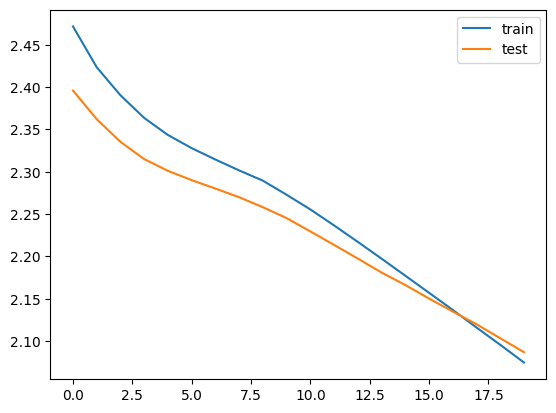

In [43]:
from matplotlib import pyplot

pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()